In [14]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, RobustScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

In [15]:
df = sns.load_dataset('titanic')
leaky_cols = ['alive', 'who', 'adult_male', 'class', 'deck', 'embark_town', 'alone']
df = df.drop(columns=leaky_cols)

KẾT QUẢ ĐÁNH GIÁ LOGISTIC REGRESSION
Accuracy : 0.8045
Precision: 0.7931
Recall   : 0.6667
F1-score : 0.7244
Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.89      0.85       110
           1       0.79      0.67      0.72        69

    accuracy                           0.80       179
   macro avg       0.80      0.78      0.79       179
weighted avg       0.80      0.80      0.80       179



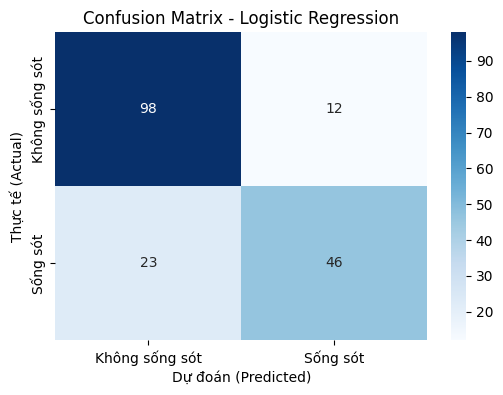

In [16]:
X = df.drop(columns=['survived'])
y = df['survived']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

num_cols = ["age", "sibsp", "parch", "fare"]
cat_cols = ["sex", "embarked"]
ord_cols = ["pclass"]

pipe_so = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler",  RobustScaler())
])

pipe_cat = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot",  OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocess = ColumnTransformer([
    ("num", pipe_so,  num_cols),
    ("cat", pipe_cat, cat_cols),
    ("ord", "passthrough", ord_cols),
])
full_pipeline = Pipeline([
    ("preprocess", preprocess),
    ("log_reg", LogisticRegression(max_iter=1000))
])
full_pipeline.fit(X_train, y_train)
y_pred = full_pipeline.predict(X_test)

print("KẾT QUẢ ĐÁNH GIÁ LOGISTIC REGRESSION")
print(f"Accuracy : {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred):.4f}")
print(f"Recall   : {recall_score(y_test, y_pred):.4f}")
print(f"F1-score : {f1_score(y_test, y_pred):.4f}")
 
print("Classification Report:")
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Không sống sót', 'Sống sót'], 
            yticklabels=['Không sống sót', 'Sống sót'])
plt.xlabel('Dự đoán (Predicted)')
plt.ylabel('Thực tế (Actual)')
plt.title('Confusion Matrix - Logistic Regression')
plt.show()

| Chỉ số đánh giá | Linear Regression | Logistic Regression |
| --- | --- | --- |
| **Accuracy** (Độ chính xác) | 79.33% | 80.45% |
| **Precision** (Độ chuẩn xác) | 75.40% | 78.00% |
| **Recall** (Độ bao phủ) | 71.01% | 71.01% |
| **F1-score** | 73.13% | 74.34% |

Regression tỏ ra phù hợp và ưu việt hơn so với Linear Regression đối với bài toán phân loại hành khách trên Titanic vì bản chất của bài toán là phân loại nhị phân chứ không phải dự đoán một giá trị liên tục.